In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# 시드 고정 (재현성)
np.random.seed(42)
torch.manual_seed(42)

In [2]:
# SGD 데이터를 한개씩 처리 분류문제에 해당특성이 잘 나타나 있음

In [3]:
X_clf, y_clf = make_classification(
    n_samples=400, n_features=2, random_state=42,
    n_informative=2, n_redundant=0,n_clusters_per_class=1,class_sep=1.5
    )
scaler = StandardScaler()
# 데이터 분할 train - test 8:2
x_train,x_test,y_train,y_test = train_test_split(X_clf,y_clf,random_state=42, stratify=y_clf,test_size=0.2)
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
# pytorch 텐서로 변환
X_clf_train_tensor = torch.tensor(x_train,dtype=torch.float32)
y_clf_train_tensor = torch.FloatTensor(y_train)
x_test_t = torch.FloatTensor(x_test)
y_test_t = torch.FloatTensor(y_test)

In [4]:
X_clf_train_tensor.shape , y_clf_train_tensor.unique()

(torch.Size([320, 2]), tensor([0., 1.]))

In [5]:
# 분류모델 정의
class BinaryClassifier(nn.Module):
  def __init__(self,input_dim, hidden_dim) -> None:
    super().__init__()
    self.fc1 = nn.Linear( input_dim , hidden_dim)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(hidden_dim ,1 )
  def forward(self, x):
    x = self.relu( self.fc1(x) )
    output = self.fc2(x)
    return output
model_clf = BinaryClassifier(2,16)
model_clf

BinaryClassifier(
  (fc1): Linear(in_features=2, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)

In [7]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model_clf.parameters(), lr=0.01,momentum=0)
x_train_dataset = TensorDataset(X_clf_train_tensor, y_clf_train_tensor)
x_train_loader = DataLoader(x_train_dataset,batch_size=1,shuffle=True)

In [8]:
# 훈련루프
from tqdm import tqdm
epochs = 100
train_losses , train_accs = [], []
for epoch in tqdm(range(epochs)):
  total_loss, total_acc = 0.0 , 0.0
  for x,y in x_train_loader:
    # 가중치 초기화
    optimizer.zero_grad()
    # forward
    predict = model_clf(x).squeeze(1)
    # loss 구하고
    loss = criterion(predict,y)
    # backward
    loss.backward()
    # 가중치 업데이트
    optimizer.step()

    total_loss += loss.item()

    predict = 1 if torch.sigmoid(predict)>=0.5 else 0
    total_acc += int(predict == int(y.item()))
  train_losses.append( total_loss / len(x_train_loader) )
  train_accs.append( total_acc / len(x_train_loader) )


100%|██████████| 100/100 [00:08<00:00, 11.24it/s]


Text(0.5, 1.0, '0.959375')

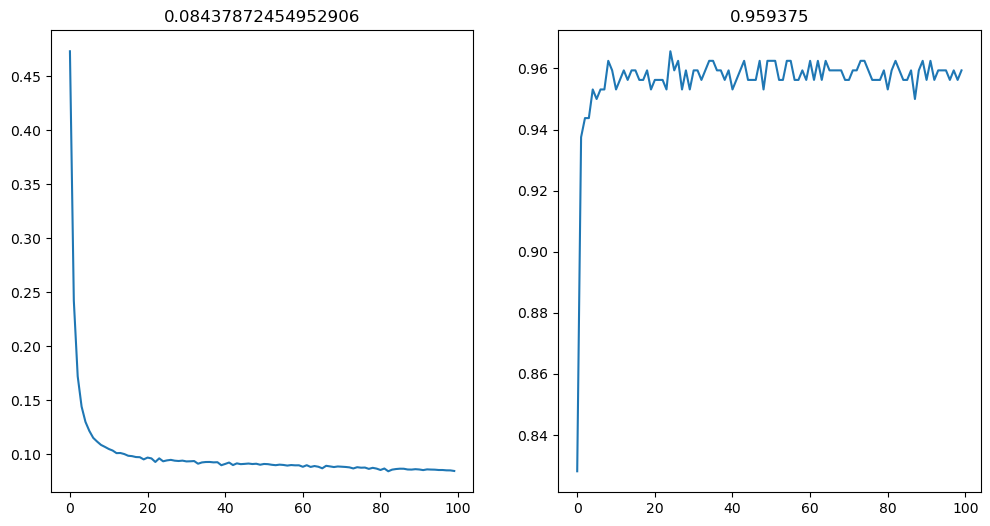

In [9]:
fig,ax = plt.subplots(1,2,figsize=(12,6))

ax[0].plot(range(epochs),train_losses)
ax[0].set_title(train_losses[-1])
ax[1].plot(range(epochs),train_accs)
ax[1].set_title(train_accs[-1])

In [ ]:
# 신경망에서 sigmoide를 추가하고 손실함수는 BCELoss(sigmoid 내장 X)  BCEWithLogitsLoss(logit대상 즉 sigmoid를 내부에적용)
# 신경망에서 마지막 출력을 2 , 손실함수는 CELoss(--> softmax 내장)

In [10]:
# 평가
with torch.no_grad():
  predict = model_clf(x_test_t).squeeze(1)
  loss = criterion(predict, y_test_t)

  predict = (torch.sigmoid(predict) >= 0.5).float()
  print(f'{loss:.4f}')
  print(accuracy_score(y_test_t, predict))

0.1668
0.925


In [11]:
# 회귀 데이터 생성
X_reg, y_reg = make_regression(
    n_samples=300,
    n_features=5,
    n_informative=5,
    noise=20.0,
    random_state=42
)
# 데이터 정규화
scaler_X_reg = StandardScaler()
X_reg = scaler_X_reg.fit_transform(X_reg)

scaler_y_reg = StandardScaler()
y_reg = scaler_y_reg.fit_transform(y_reg.reshape(-1, 1)).flatten()

# 학습/테스트 분할 (80/20)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# PyTorch 텐서로 변환
X_reg_train_tensor = torch.FloatTensor(X_reg_train)
y_reg_train_tensor = torch.FloatTensor(y_reg_train).reshape(-1, 1)
X_reg_test_tensor = torch.FloatTensor(X_reg_test)
y_reg_test_tensor = torch.FloatTensor(y_reg_test).reshape(-1, 1)

print(f"회귀 데이터셋 생성 완료")
print(f"훈련 데이터: {X_reg_train_tensor.shape}")
print(f"테스트 데이터: {X_reg_test_tensor.shape}")
print(f"목표값 범위: [{y_reg.min():.4f}, {y_reg.max():.4f}]")

회귀 데이터셋 생성 완료
훈련 데이터: torch.Size([240, 5])
테스트 데이터: torch.Size([60, 5])
목표값 범위: [-2.4866, 2.6997]


In [12]:
class RegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(5, 16)
        self.fc2 = nn.Linear(16, 1)
    def forward(self, x):
        x = nn.ReLU()(self.fc1(x))
        output = self.fc2(x)
        return output
model_reg =  RegressionModel()

In [13]:
# SGD 최적화기 설정 (회귀용)
criterion_reg = nn.MSELoss()  # 회귀 손실함수: MSE
optimizer_sgd_reg = optim.SGD(model_reg.parameters(), lr=0.01, momentum=0)

# DataLoader (batch_size=1 for true SGD)
reg_dataset = TensorDataset(X_reg_train_tensor, y_reg_train_tensor)
reg_loader = DataLoader(reg_dataset, batch_size=1, shuffle=True)

# 훈련 루프
num_epochs = 150
train_losses_reg = []
train_r2_scores = []

from tqdm import tqdm
for epoch in tqdm(range(num_epochs)):
    total_loss = 0
    all_predictions = []
    all_targets = []

    for X_batch, y_batch in reg_loader:
        optimizer_sgd_reg.zero_grad()
        # Forward pass
        outputs = model_reg(X_batch)
        # Backward pass + SGD 업데이트
        loss = criterion_reg(outputs, y_batch)
        loss.backward()
        optimizer_sgd_reg.step()

        total_loss += loss.item() * X_batch.size(0)  # torch size는 shape

        # R² 점수 계산을 위한 데이터 수집
        with torch.no_grad():
            all_predictions.append(outputs.item())
            all_targets.append(y_batch.item())

    avg_loss = total_loss / len(reg_loader)
    r2 = r2_score(all_targets, all_predictions)
    train_losses_reg.append(avg_loss)
    train_r2_scores.append(r2)

    if (epoch + 1) % 30 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}, R²: {r2:.4f}")

print("\n회귀 모델 훈련 완료!")

 21%|██▏       | 32/150 [00:02<00:07, 14.93it/s]

Epoch [30/150] Loss: 0.0318, R²: 0.9688


 41%|████▏     | 62/150 [00:04<00:05, 15.71it/s]

Epoch [60/150] Loss: 0.0294, R²: 0.9712


 61%|██████▏   | 92/150 [00:06<00:03, 15.55it/s]

Epoch [90/150] Loss: 0.0277, R²: 0.9728


 81%|████████▏ | 122/150 [00:08<00:01, 15.23it/s]

Epoch [120/150] Loss: 0.0271, R²: 0.9734


100%|██████████| 150/150 [00:09<00:00, 15.21it/s]

Epoch [150/150] Loss: 0.0253, R²: 0.9752

회귀 모델 훈련 완료!


In [14]:
# 테스트 데이터에 대한 평가
with torch.no_grad():
    y_pred_reg = model_reg(X_reg_test_tensor)
    test_mse = mean_squared_error(y_reg_test_tensor.numpy(), y_pred_reg.numpy())
    test_r2 = r2_score(y_reg_test_tensor.numpy(), y_pred_reg.numpy())
    test_rmse = np.sqrt(test_mse)

print("\n[회귀 문제 결과]")
print(f"테스트 MSE: {test_mse:.4f}")
print(f"테스트 RMSE: {test_rmse:.4f}")
print(f"테스트 R²: {test_r2:.4f}")


[회귀 문제 결과]
테스트 MSE: 0.0444
테스트 RMSE: 0.2106
테스트 R²: 0.9518


In [15]:
[model_clf.fc1.in_features]+[ model_clf.fc1.out_features]

[2, 16]

In [16]:
model = BinaryClassifier(2,16)
criterion_local = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0)
dataset = TensorDataset(X_clf_train_tensor, y_clf_train_tensor)
loader = DataLoader(dataset, batch_size=1, shuffle=True)
for X_batch, y_batch in loader:
  outputs = model(X_batch).squeeze(0)
  loss = criterion_local(outputs, y_batch)


In [17]:
def train_with_batch_size(model_template, X_train, y_train, criterion, batch_size, num_epochs, lr=0.01):
    """
    다양한 배치 크기로 훈련하는 함수

    배치 크기에 따른 특성:
    - batch_size=1: 진정한 SGD (단일 샘플마다 업데이트)
    - batch_size=16-32: Mini-batch (선호되는 실무 방식)
    - batch_size=len(data): Full Batch GD (전체 데이터)
    """
    model = model_template.__class__(*([model_template.fc1.in_features] +
                                       [model_template.fc1.out_features]))
    criterion_local = criterion.__class__()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0)

    dataset = TensorDataset(X_train, y_train)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    losses = []

    for epoch in range(num_epochs):
        total_loss = 0
        for X_batch, y_batch in loader:
            outputs = model(X_batch).squeeze(1)
            loss = criterion_local(outputs, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * X_batch.size(0)

        avg_loss = total_loss / len(X_train)
        losses.append(avg_loss)

    return model, losses

# 세 가지 배치 크기로 비교
print("SGD vs Mini-Batch vs Batch GD 훈련 중...")

model_sgd, losses_sgd = train_with_batch_size(
    model_clf, X_clf_train_tensor, y_clf_train_tensor,
    nn.BCEWithLogitsLoss(), batch_size=1, num_epochs=100, lr=0.01
)
print(" SGD (batch_size=1) 완료")

model_mb, losses_mb = train_with_batch_size(
    model_clf, X_clf_train_tensor, y_clf_train_tensor,
    nn.BCEWithLogitsLoss(), batch_size=16, num_epochs=100, lr=0.01
)
print(" Mini-Batch (batch_size=16) 완료")

model_bg, losses_bg = train_with_batch_size(
    model_clf, X_clf_train_tensor, y_clf_train_tensor,
    nn.BCEWithLogitsLoss(), batch_size=len(X_clf_train_tensor), num_epochs=100, lr=0.01
)
print(" Batch GD (batch_size=전체) 완료")

SGD vs Mini-Batch vs Batch GD 훈련 중...
 SGD (batch_size=1) 완료
 Mini-Batch (batch_size=16) 완료
 Batch GD (batch_size=전체) 완료


3가지 방식 시각화 비교

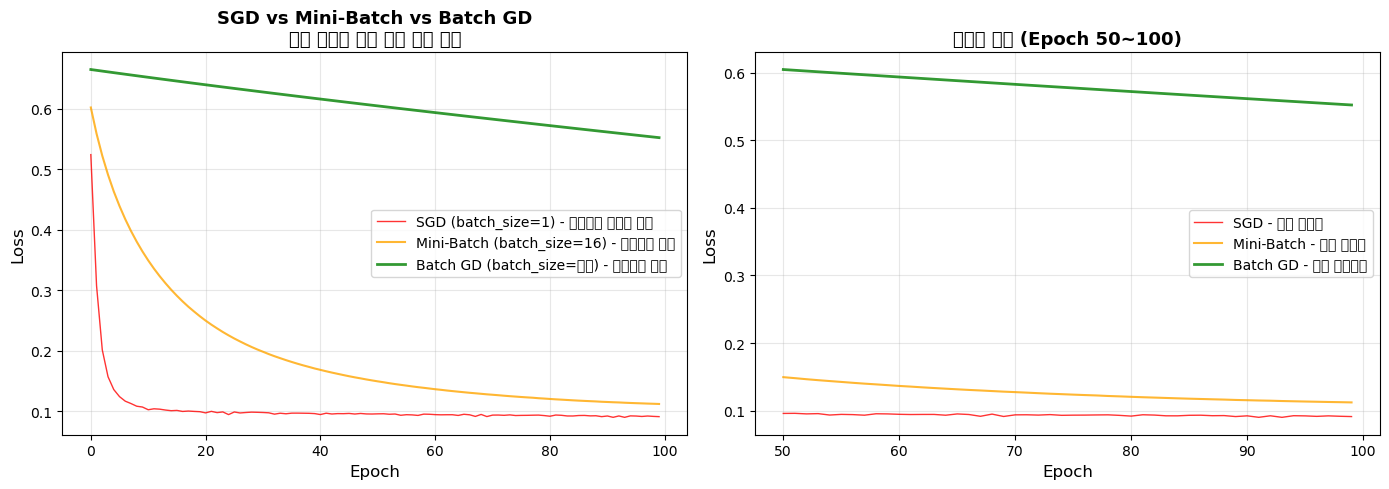

비교 그래프 저장 완료: 01_SGD_Comparison.png


In [18]:
plt.figure(figsize=(14, 5))

# 왼쪽: 전체 학습 곡선
plt.subplot(1, 2, 1)
plt.plot(losses_sgd, linewidth=1, alpha=0.8, label='SGD (batch_size=1) - 지그재그 변동성 높음', color='red')
plt.plot(losses_mb, linewidth=1.5, alpha=0.8, label='Mini-Batch (batch_size=16) - 균형잡힌 방식', color='orange')
plt.plot(losses_bg, linewidth=2, alpha=0.8, label='Batch GD (batch_size=전체) - 부드러운 수렴', color='green')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('SGD vs Mini-Batch vs Batch GD\n배치 크기에 따른 학습 곡선 비교', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# 오른쪽: 마지막 50 에포크 확대
plt.subplot(1, 2, 2)
start_idx = 50
plt.plot(range(start_idx, 100), losses_sgd[start_idx:], linewidth=1, alpha=0.8, label='SGD - 높은 변동성', color='red')
plt.plot(range(start_idx, 100), losses_mb[start_idx:], linewidth=1.5, alpha=0.8, label='Mini-Batch - 낮은 변동성', color='orange')
plt.plot(range(start_idx, 100), losses_bg[start_idx:], linewidth=2, alpha=0.8, label='Batch GD - 가장 부드러움', color='green')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('후반부 확대 (Epoch 50~100)', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_SGD_Comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("비교 그래프 저장 완료: 01_SGD_Comparison.png")

수치적 비교 분석

In [19]:
print("\n" + "="*70)
print("SGD vs Mini-Batch vs Batch GD 수치 비교")
print("="*70)

# 학습 안정성 분석
sgd_variance = np.var(losses_sgd[50:])  # 후반부 변동성
mb_variance = np.var(losses_mb[50:])
bg_variance = np.var(losses_bg[50:])

print(f"\n1. 학습 안정성 (후반부 손실값 분산):")
print(f"   - SGD (batch_size=1):        {sgd_variance:.6f}  (변동성 높음 )")
print(f"   - Mini-Batch (batch_size=16): {mb_variance:.6f}  (균형)")
print(f"   - Batch GD (batch_size=전체): {bg_variance:.6f}  (안정적 ✓)")

# 최종 손실값
print(f"\n2. 최종 손실값 (100 에포크 후):")
print(f"   - SGD:           {losses_sgd[-1]:.6f}")
print(f"   - Mini-Batch:    {losses_mb[-1]:.6f}")
print(f"   - Batch GD:      {losses_bg[-1]:.6f}")

# 수렴 속도 (처음 50 에포크에서의 손실 감소)
print(f"\n3. 초기 수렴 속도 (Epoch 1→50에서의 손실 감소):")
sgd_improvement = (losses_sgd[0] - losses_sgd[49]) / losses_sgd[0] * 100
mb_improvement = (losses_mb[0] - losses_mb[49]) / losses_mb[0] * 100
bg_improvement = (losses_bg[0] - losses_bg[49]) / losses_bg[0] * 100

print(f"   - SGD:           {sgd_improvement:.2f}% 감소")
print(f"   - Mini-Batch:    {mb_improvement:.2f}% 감소")
print(f"   - Batch GD:      {bg_improvement:.2f}% 감소")

print(f"\n" + "="*70)
print(" 결론:")
print("="*70)
print("✓ SGD (배치크기=1):")
print("  - 장점: 데이터 한 개씩 빠르게 학습, 지역최솟값 탈출 유리")
print("  - 단점: 학습이 불안정하고 변동이 큼")
print()
print("✓ Mini-Batch (배치크기=16):")
print("  - 장점: SGD의 속도와 BGD의 안정성을 모두 제공")
print("  - 추천: 현대 딥러닝의 가장 일반적인 방식 ")
print()
print("✓ Batch GD (배치크기=전체):")
print("  - 장점: 가장 안정적이고 부드러운 수렴")
print("  - 단점: 대규모 데이터에서는 메모리 부담이 큼")
print()


SGD vs Mini-Batch vs Batch GD 수치 비교

1. 학습 안정성 (후반부 손실값 분산):
   - SGD (batch_size=1):        0.000002  (변동성 높음 )
   - Mini-Batch (batch_size=16): 0.000116  (균형)
   - Batch GD (batch_size=전체): 0.000238  (안정적 ✓)

2. 최종 손실값 (100 에포크 후):
   - SGD:           0.091429
   - Mini-Batch:    0.112359
   - Batch GD:      0.552101

3. 초기 수렴 속도 (Epoch 1→50에서의 손실 감소):
   - SGD:           81.73% 감소
   - Mini-Batch:    74.87% 감소
   - Batch GD:      8.87% 감소

 결론:
✓ SGD (배치크기=1):
  - 장점: 데이터 한 개씩 빠르게 학습, 지역최솟값 탈출 유리
  - 단점: 학습이 불안정하고 변동이 큼

✓ Mini-Batch (배치크기=16):
  - 장점: SGD의 속도와 BGD의 안정성을 모두 제공
  - 추천: 현대 딥러닝의 가장 일반적인 방식 

✓ Batch GD (배치크기=전체):
  - 장점: 가장 안정적이고 부드러운 수렴
  - 단점: 대규모 데이터에서는 메모리 부담이 큼

